In [225]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
random.seed(20)
np.random.seed(10)

Exercício 10, lista 2

função para plotar a superfície de erro

In [226]:
def calculateErrorSurface(X, y):
    """
    Generate data points for plotting the error surface.
    X: design matrix
    y: labels (y = a1*x1 + a2*x2)
    A1, A2: meshgrid of the attributes
    J: MSE surface
    """
    # Get the number of examples.
    N = len(y)

    # Generate values for parameters.
    M = 100
    a1 = np.linspace(-12.0, 14.0, M)
    a2 = np.linspace(-12.0, 14.0, M)
    # Generate the mesh grid.
    A1, A2 = np.meshgrid(a1, a2)

    # Get the attributes
    x1 = X[:,0].reshape(N, 1)
    x2 = X[:,1].reshape(N, 1)
    # Generate points for plotting the cost-function surface.
    J = np.zeros((M,M))
    for iter1 in range(0, M):
        for iter2 in range(0, M):
            # Hypothesis function.
            yhat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2
            # Calculate the MSE.
            J[iter1, iter2] = (1.0/N)*np.sum(np.square(y - yhat))
            
    

    return J, A1, A2

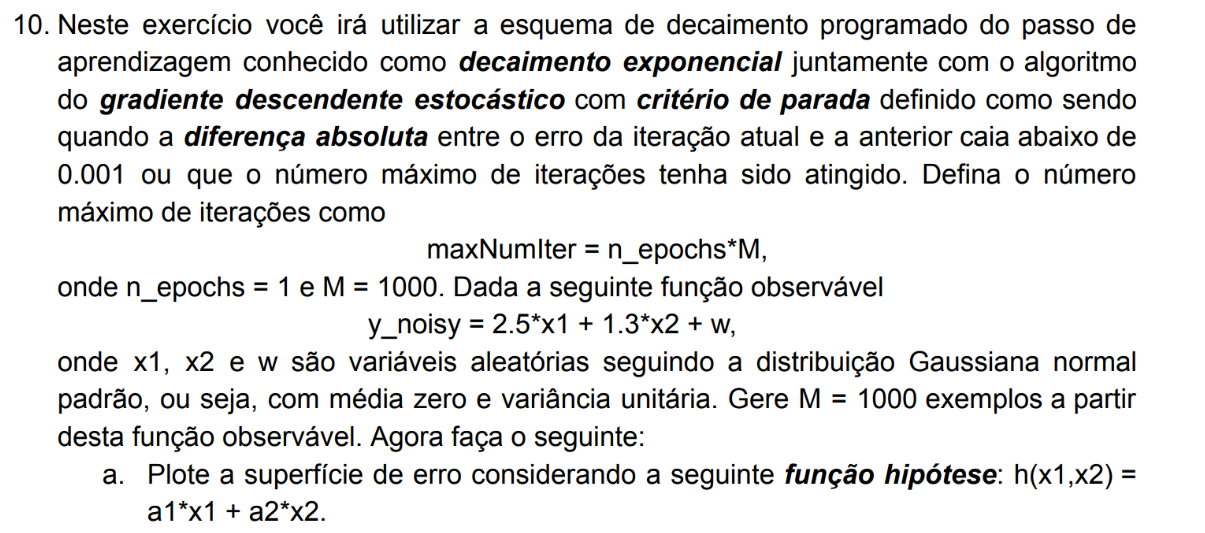

In [227]:
def stochastic_gradient_descent(X,y,epochs,N,alpha):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    N: number of examples
    alpha: learning rate/step size
    """
    m = X.shape[1] #number of attributes
    
    a = 10 * np.ones(m).reshape(2,1) # initial column vector of weights

    a_hist = np.zeros((epochs*N+1,m)) # matrix that stores the weight history
    a_hist[0,:] = a.reshape(1,m)

    mse_hist = np.zeros((epochs*N+1)) # matrix that stores the error history
    mse_hist[0] = (1/N) * np.sum((y- (X @ a))**2)
    update_hist = np.zeros((epochs*N,m)) # matrix that stores learning rate * gradient
    it=0 #apenas preenche os vetores de historico, variaveu auxiliar

    random.seed(20)
    np.random.seed(10)
    
    
    for e in range(epochs):
        shuffled_indexes = random.sample(range(0, N), N) # Shuffling the whole dataset before every epoch.
        i = 0 #iteration count
        abs_error = np.inf
        #and abs_error > 0.001
        while i < N :
            # Randomly selecting 1 training example 
            random_index = shuffled_indexes[i]
            xi = X[random_index,:].reshape(m,1)
            yi = y[random_index].reshape(1,1)

            yi_hat = a.T @ xi                    # funcao hipotese
            grad = (-2 * (xi @ (yi-yi_hat) ))    # column vector of the gradient of the mse function
            a = a - alpha * grad                 # weight update

            # Saving the histories
            a_hist[it,:] = a.reshape(1,m)
            mse_hist[it] = (1/N) * np.sum((yi-yi_hat)**2)
            update_hist[it,:] = (alpha * grad).reshape(1,m)
            it+=1
            i+=1
            abs_error = np.abs(mse_hist[it-1] - mse_hist[it])

    return a, a_hist, mse_hist, update_hist, it

In [228]:
"""m = 1000 #quantidade de exemplos
x1 = np.random.randn(m)
x2 = np.random.randn(m)
w = np.random.randn(m)
y_noisy = 2.5 * x1 + 1.3 * x2 + w  #função observável
X = np.c_[x1,x2]

J, A1, A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(5,5))
plt.subplot(projection='3d')
ax = fig.gca()
surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('Cost-function\'s surface', fontsize=14)
ax.view_init(20, 45)
ax.zaxis.labelpad=-3
#Show the plot.
plt.show()"""

"m = 1000 #quantidade de exemplos\nx1 = np.random.randn(m)\nx2 = np.random.randn(m)\nw = np.random.randn(m)\ny_noisy = 2.5 * x1 + 1.3 * x2 + w  #função observável\nX = np.c_[x1,x2]\n\nJ, A1, A2 = calculateErrorSurface(X,y_noisy)\nfig = plt.figure(figsize=(5,5))\nplt.subplot(projection='3d')\nax = fig.gca()\nsurf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)\nax.set_xlabel('$a_1$', fontsize=14)\nax.set_ylabel('$a_2$', fontsize=14)\nax.set_zlabel('$J_e$', fontsize=14);\nplt.title('Cost-function's surface', fontsize=14)\nax.view_init(20, 45)\nax.zaxis.labelpad=-3\n#Show the plot.\nplt.show()"

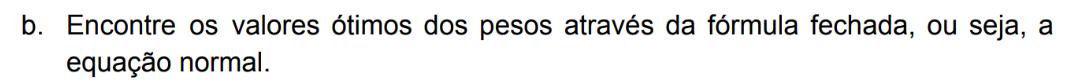

In [229]:
w_opt = np.linalg.inv(X.T @ X) @ X.T @ y_noisy
print(w_opt)

[2.49708072 1.23386595]


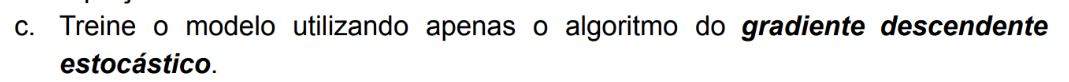

In [230]:
n_epochs = 1
w_e, w_e_hist, mse_e_hist, update_hist,it = stochastic_gradient_descent(X,y_noisy,n_epochs,m,0.01)

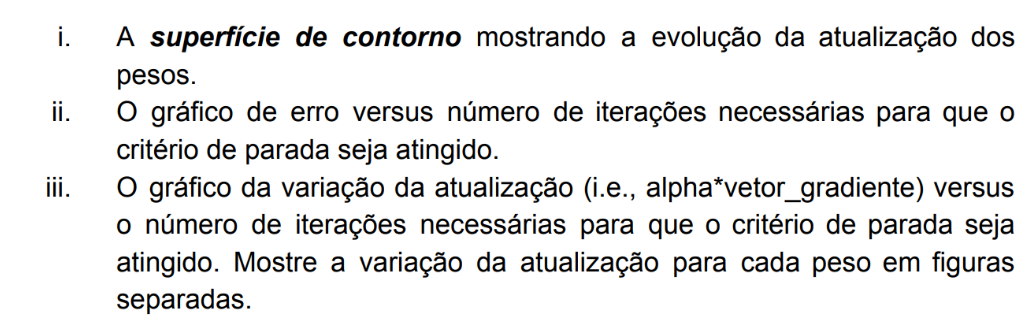

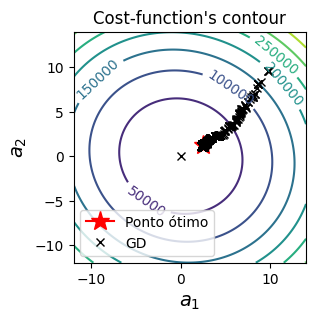

In [231]:
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(w_opt[0], w_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(w_e_hist[:, 0], w_e_hist[:, 1], 'kx', label='GD')

plt.legend()
plt.show()

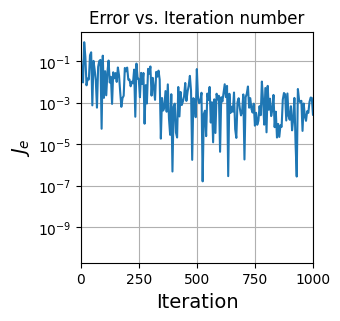

In [232]:
fig = plt.figure(figsize=(3,3))

plt.plot(np.arange(0, 5*len(mse_e_hist),5), mse_e_hist[:])
plt.xlim((0, len(mse_e_hist)))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)
plt.title('Error vs. Iteration number')
plt.grid()
plt.show()

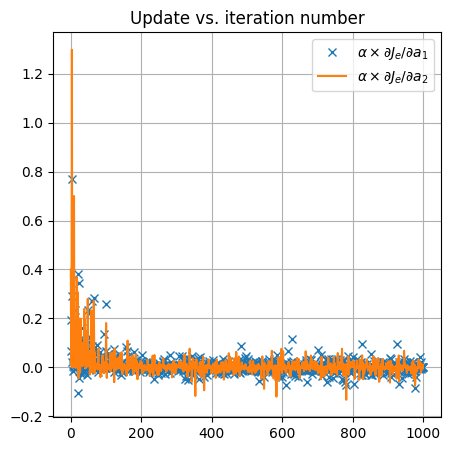

In [233]:
fig = plt.figure(figsize=(5,5))
plt.plot(np.arange(0, n_epochs*m), update_hist[:, 0], 'x', label='$\\alpha \\times \partial J_{e} / \partial a_1$')
plt.plot(np.arange(0, n_epochs*m), update_hist[:, 1], label='$\\alpha \\times \partial J_{e} / \partial a_2$')

plt.title('Update vs. iteration number')
plt.legend()
plt.grid()

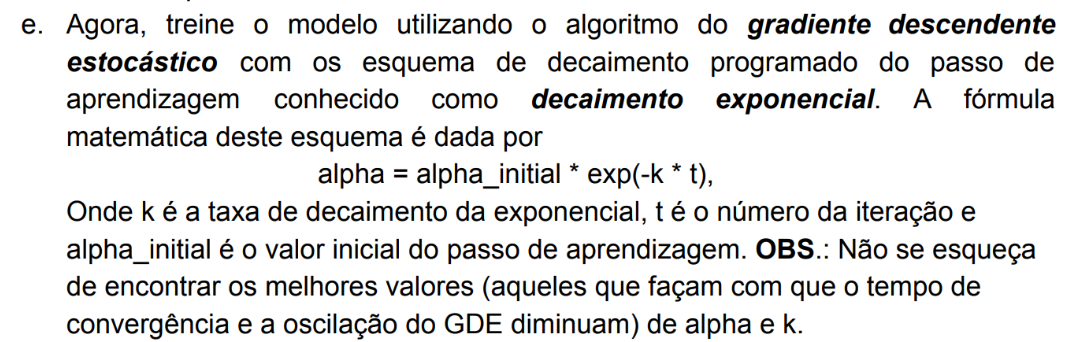

gradiente descendente usando decaimento exponencial

In [234]:
def stochastic_gradient_descent_exponential_decay(X,y,epochs,N,alpha_0,k):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    N: number of examples
    alpha: learning rate/step size
    """
    m = X.shape[1] #number of attributes
    
    a = 10 * np.ones(m).reshape(2,1) # initial column vector of weights

    a_hist = np.zeros((epochs*N+1,m)) # matrix that stores the weight history
    a_hist[0,:] = a.reshape(1,m)

    mse_hist = np.zeros((epochs*N+1)) # matrix that stores the error history
    mse_hist[0] = (1/N) * np.sum((y- (X @ a))**2)
    update_hist = np.zeros((epochs*N,m)) # matrix that stores learning rate * gradient
    it=0 #apenas preenche os vetores de historico, variaveu auxiliar
    random.seed(20)
    np.random.seed(10)

    
    for e in range(epochs):
        shuffled_indexes = random.sample(range(0, N), N) # Shuffling the whole dataset before every epoch.
        i = 0 #iteration count
        abs_error = np.inf
        
        while i < N:
            # Randomly selecting 1 training example 
            random_index = shuffled_indexes[i]
            xi = X[random_index,:].reshape(m,1)
            yi = y[random_index].reshape(1,1)

            alpha = alpha_0 * np.exp(-k*it)      # LEARNING RATE WITH EXPONENTIAL DECAY
            yi_hat = a.T @ xi                    # funcao hipotese
            grad = (-2 * (xi @ (yi-yi_hat) ))    # column vector of the gradient of the mse function
            a = a - alpha * grad                 # weight update

            # Saving the histories
            a_hist[it,:] = a.reshape(1,m)
            mse_hist[it] = (1/N) * np.sum((yi-yi_hat)**2)
            update_hist[it,:] = (alpha * grad).reshape(1,m)
            it+=1
            i+=1
            

    return a, a_hist, mse_hist, update_hist, it

grid search para encontrar o melhor valor de k

In [235]:
def grid_search(X,y_noisy,n_epochs,m,initial_alpha):
    maxEpochs = 1000
    # 1° fase: ajuste grosso (escala logaritmica)
    decrease_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1] 

    scores = []
    for i in range(0,len(decrease_rates)):
        inital_alpha = 0.01
        w, w_hist, mse_hist, update_hist,it = stochastic_gradient_descent_exponential_decay(X,y_noisy,n_epochs,m,inital_alpha,decrease_rates[i])
        scores.append((1/m) * np.sum((y_noisy - X @ w)**2)) 
    
    # 2° fase: ajuste fino em torno do melhor valor
    scores = np.array(scores)
    best_score = scores.argmin()
    best_rate = decrease_rates[best_score]
    decrease_rates = np.arange(best_rate/5, best_rate*5)

    scores = []
    for i in range(0,len(decrease_rates)):
        inital_alpha = 0.01
        w, w_hist, mse_hist, update_hist,it = stochastic_gradient_descent_exponential_decay(X,y_noisy,n_epochs,m,inital_alpha,decrease_rates[i])
        scores.append((1/m) * np.sum((y_noisy - X @ w)**2))  
        

    scores = np.array(scores)
    best_score = scores.argmin()
    best_rate = decrease_rates[best_score]
    return best_rate
    


In [236]:
k = grid_search(X,y_noisy,n_epochs,m,0.01)
w_exp, w_exp_hist, mse_exp_hist, update_exp_hist, it = stochastic_gradient_descent_exponential_decay(X,y_noisy,n_epochs,m,0.01,k)
print(w_exp)

[[2.53884158]
 [1.39266457]]


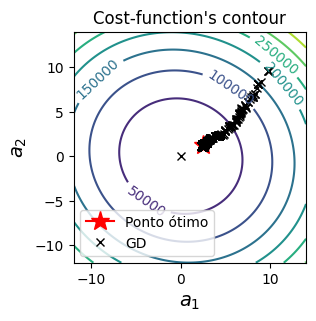

In [237]:
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(w_opt[0], w_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(w_exp_hist[:, 0], w_exp_hist[:, 1], 'kx', label='GD')

plt.legend()
plt.show()

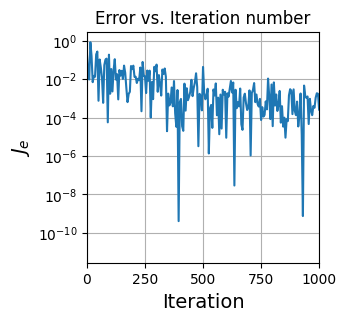

In [238]:
fig = plt.figure(figsize=(3,3))

plt.plot(np.arange(0, 5*len(mse_exp_hist),5), mse_exp_hist[:])
plt.xlim((0, len(mse_exp_hist)))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)
plt.title('Error vs. Iteration number')
plt.grid()
plt.show()

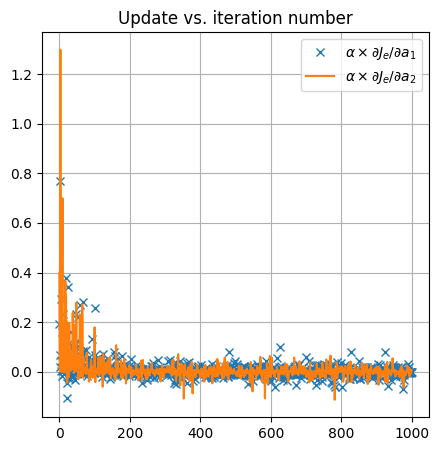

In [239]:
fig = plt.figure(figsize=(5,5))
plt.plot(np.arange(0, n_epochs*m), update_exp_hist[:, 0], 'x', label='$\\alpha \\times \partial J_{e} / \partial a_1$')
plt.plot(np.arange(0, n_epochs*m), update_exp_hist[:, 1], label='$\\alpha \\times \partial J_{e} / \partial a_2$')

plt.title('Update vs. iteration number')
plt.legend()
plt.grid()

Comparação dos pesos

In [240]:
print("Eq. Normal")
print(w_opt)
print("GDE")
print(w_e)
print("GDE Decaimento exp")
print(w_exp)

Eq. Normal
[2.49708072 1.23386595]
GDE
[[2.54004545]
 [1.41540036]]
GDE Decaimento exp
[[2.53884158]
 [1.39266457]]
